In [2]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv("diabetes.csv")

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [48]:
x=df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]  #dataframe
y=df["Outcome"]              #series
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)
x_train, x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=.20,random_state=12)

In [49]:
svc = SVC()

In [50]:
svc.fit(x_train,y_train)

SVC()

In [51]:
y_pred=svc.predict(x_test)

In [52]:
x_pred=svc.predict(x_train)

In [53]:
acc=accuracy_score(y_test,y_pred)
acc

0.8051948051948052

In [54]:
conf_mat=confusion_matrix(y_test,y_pred)
conf_mat

array([[92,  7],
       [23, 32]])

In [55]:
clas_rpt= classification_report(y_test,y_pred)
clas_rpt

'              precision    recall  f1-score   support\n\n           0       0.80      0.93      0.86        99\n           1       0.82      0.58      0.68        55\n\n    accuracy                           0.81       154\n   macro avg       0.81      0.76      0.77       154\nweighted avg       0.81      0.81      0.80       154\n'

NameError: name 'plt' is not defined

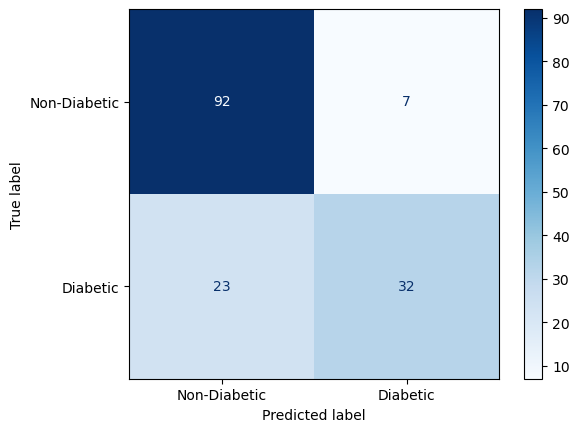

In [56]:
# Plot actual vs predicted values
from sklearn.metrics import ConfusionMatrixDisplay
disp=ConfusionMatrixDisplay(confusion_matrix=conf_mat,display_labels=["Non-Diabetic","Diabetic"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")